

# Import libraries

In [24]:
# !  pip install lightgbm

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
from scipy import stats
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, f1_score
import lightgbm as lgb

# Set plot style
sns.set(style="whitegrid")

In [26]:
file_path = "data.csv"
df = pd.read_csv(file_path)

# Display the first few rows
print("First 5 rows of the dataset:")
display(df.head())

First 5 rows of the dataset:


,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,...,RemoteWork,MonthlyIncome,StressRating,WelfareBenefits,InHouseFacility,ExternalFacility,ExtendedLeave,FlexibleWork,StressSelfReported,Year
0,41,Yes,Travel_Rarely,Sales,1,2,Life Sciences,1,1,2,...,1,5224,4,1,0,0,0,0,1,2023
1,49,No,Travel_Frequently,Research & Development,8,1,Life Sciences,1,2,3,...,3,6863,2,4,1,0,0,1,1,2023
2,37,Yes,Travel_Rarely,Research & Development,2,2,Other,1,4,4,...,2,7612,3,2,1,0,0,0,1,2023
3,33,No,Travel_Frequently,Research & Development,3,4,Life Sciences,1,5,4,...,2,11245,1,4,1,1,1,1,1,2023
4,27,No,Travel_Rarely,Research & Development,2,1,Medical,1,7,1,...,2,3029,3,2,0,0,0,0,3,2023


## Exploratory Data Analysis (EDA)

In [27]:
# Check dataset shape
print(f"The dataset has {df.shape[0]} rows and {df.shape[1]} columns.")

# Check data types and missing values
print("\nDataset Info:")
df.info()

The dataset has 1470 rows and 44 columns.

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 44 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   Department                1470 non-null   str  
 4   DistanceFromHome          1470 non-null   int64
 5   Education                 1470 non-null   int64
 6   EducationField            1470 non-null   str  
 7   EmployeeCount             1470 non-null   int64
 8   EmployeeNumber            1470 non-null   int64
 9   EnvironmentSatisfaction   1470 non-null   int64
 10  Gender                    1470 non-null   str  
 11  PerformanceIndex          1470 non-null   int64
 12  JobInvolvement            1470 non-null   int64
 13  JobLevel                  1470 non-null   int64

## Target Variable Analysis

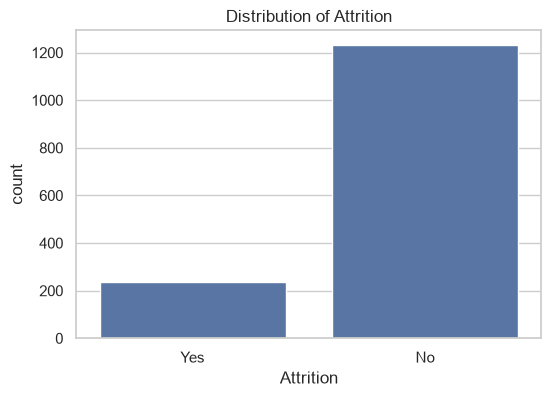

Attrition Rate:
Attrition
No     83.809524
Yes    16.190476
Name: proportion, dtype: float64


In [28]:
# Visualize Target Variable
plt.figure(figsize=(6, 4))
sns.countplot(x='Attrition', data=df)
plt.title('Distribution of Attrition')
plt.show()

# Calculate Attrition Rate
attrition_rate = df['Attrition'].value_counts(normalize=True) * 100
print("Attrition Rate:")
print(attrition_rate)

## Feature Analysis & Correlation with Attrition

### Visualizing Numerical Features

Total numerical features to plot: 33
Skipped 2 constant columns


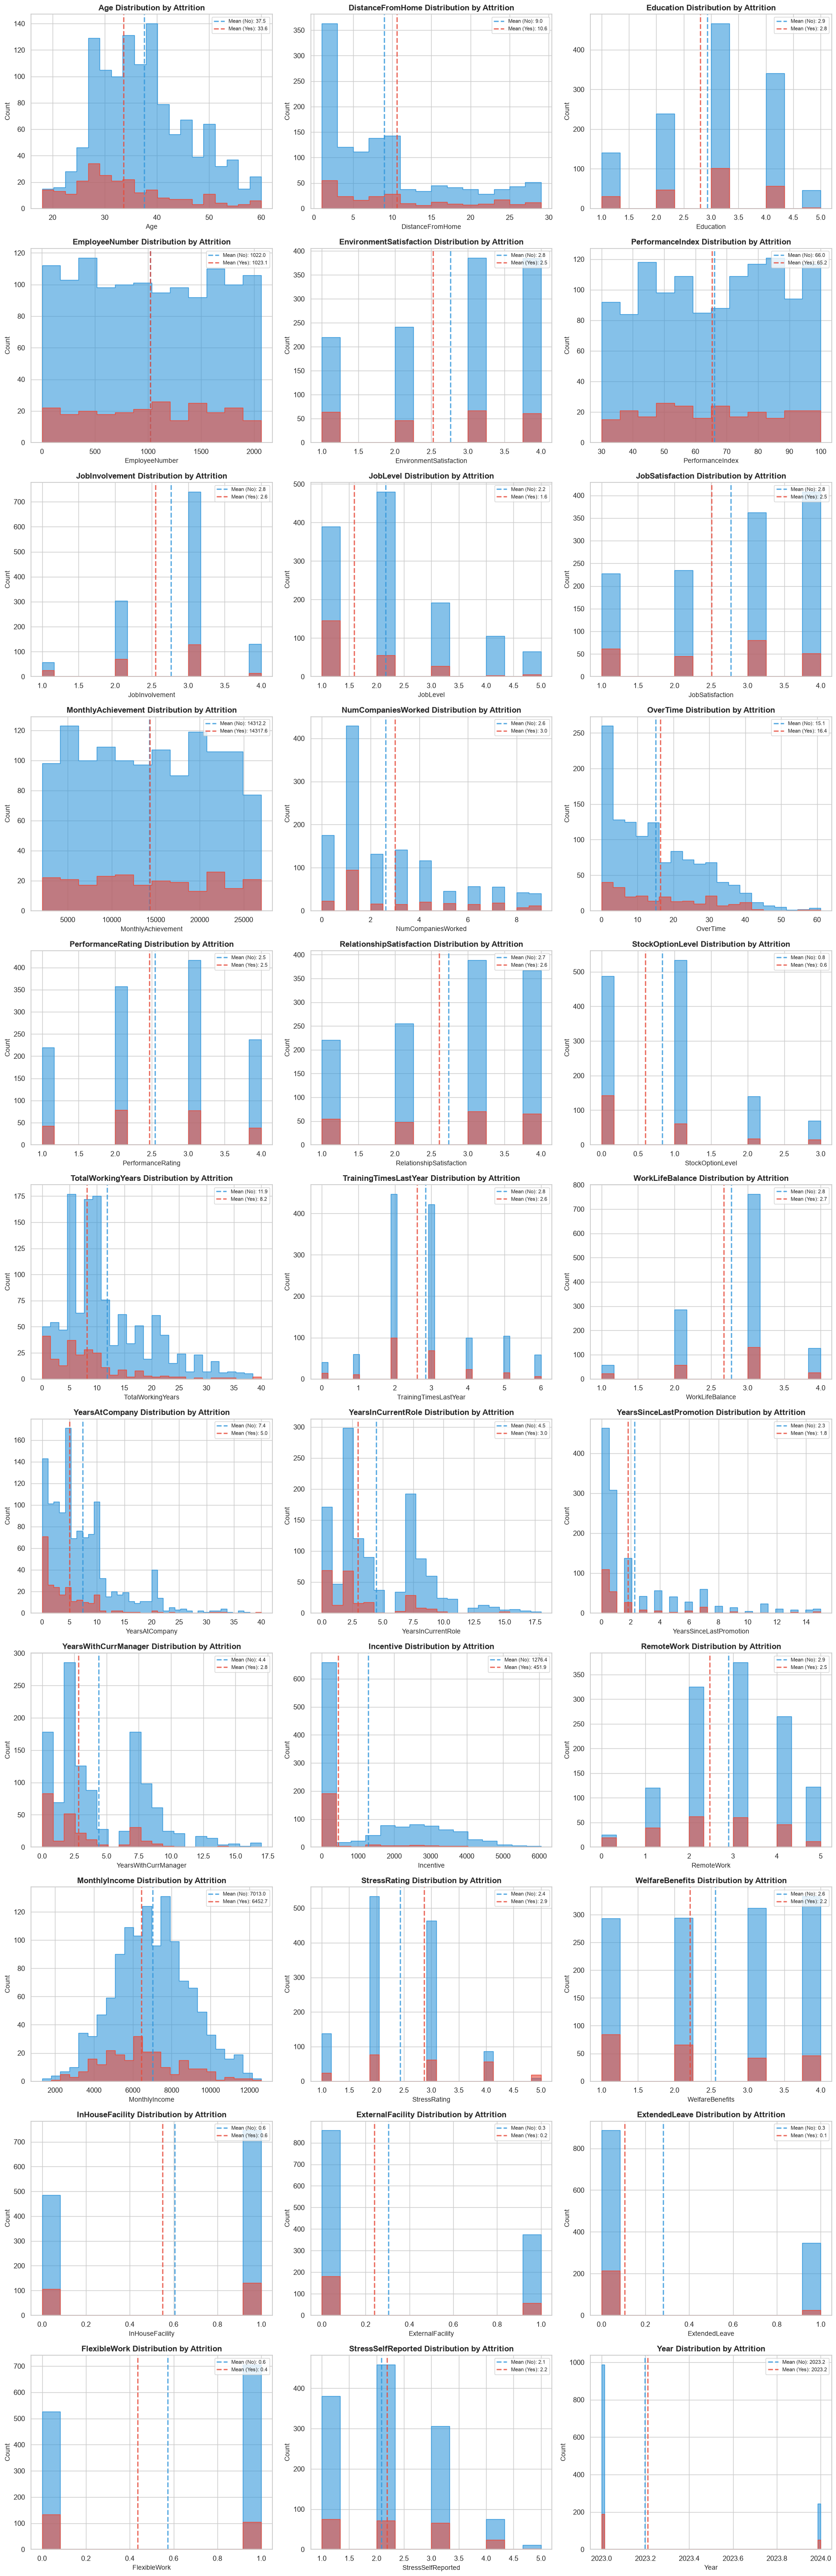

In [29]:
# Select ALL numerical columns (excluding target)
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
if 'Attrition' in num_cols:
    num_cols.remove('Attrition')

# Filter out constant columns (zero variance) as they can't be visualized meaningfully
cols_to_plot = [col for col in num_cols if df[col].nunique() > 1]

print(f'Total numerical features to plot: {len(cols_to_plot)}')
print(f'Skipped {len(num_cols) - len(cols_to_plot)} constant columns')

# Calculate grid size
n_cols_to_plot = len(cols_to_plot)
n_rows = math.ceil(n_cols_to_plot / 3)
n_cols_grid = min(3, n_cols_to_plot)

# Plot configurations
fig, axes = plt.subplots(n_rows, n_cols_grid, figsize=(18, n_rows * 5))

# Flatten axes if it's 2D
if n_cols_to_plot == 1:
    axes = [axes]
elif n_rows > 1:
    axes = axes.flatten()

# Plot numerical features by Attrition with mean lines
for i, col in enumerate(cols_to_plot):
    # Calculate means for each group
    mean_no = df[df['Attrition'] == 'No'][col].mean()
    mean_yes = df[df['Attrition'] == 'Yes'][col].mean()

    sns.histplot(data=df, x=col, hue='Attrition', hue_order=['Yes', 'No'], kde=False, element='step',
                    ax=axes[i], palette=['#e74c3c', '#3498db'], alpha=0.6)

    # Add vertical lines for means
    axes[i].axvline(mean_no, color='#3498db', linestyle='--', linewidth=2, alpha=0.8,
                    label=f'Mean (No): {mean_no:.1f}')
    axes[i].axvline(mean_yes, color='#e74c3c', linestyle='--', linewidth=2, alpha=0.8,
                    label=f'Mean (Yes): {mean_yes:.1f}')

    axes[i].set_title(f'{col} Distribution by Attrition', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col, fontsize=10)
    axes[i].set_ylabel('Count', fontsize=10)
    axes[i].legend(fontsize=8, loc='upper right')

    # Ensure legend order matches visual: No (blue) first, then Yes (red)
    handles, labels = axes[i].get_legend_handles_labels()
    # Reorder to ensure No comes before Yes
    if len(labels) >= 2:
        # Check current order and swap if needed
        if labels[0] == 'Yes':
            handles = [handles[1], handles[0]]
            labels = [labels[1], labels[0]]
        axes[i].legend(handles, labels, fontsize=8, loc='upper right')

# Hide extra subplots if any
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

#### Key Insights from Numerical Features:

### Visualizing Categorical Features

/var/folders/9x/dqbd0vwn2573yqw6z7s2g8_r0000gn/T/ipykernel_74602/2801634477.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  obj_cols = df.select_dtypes(include="object").columns


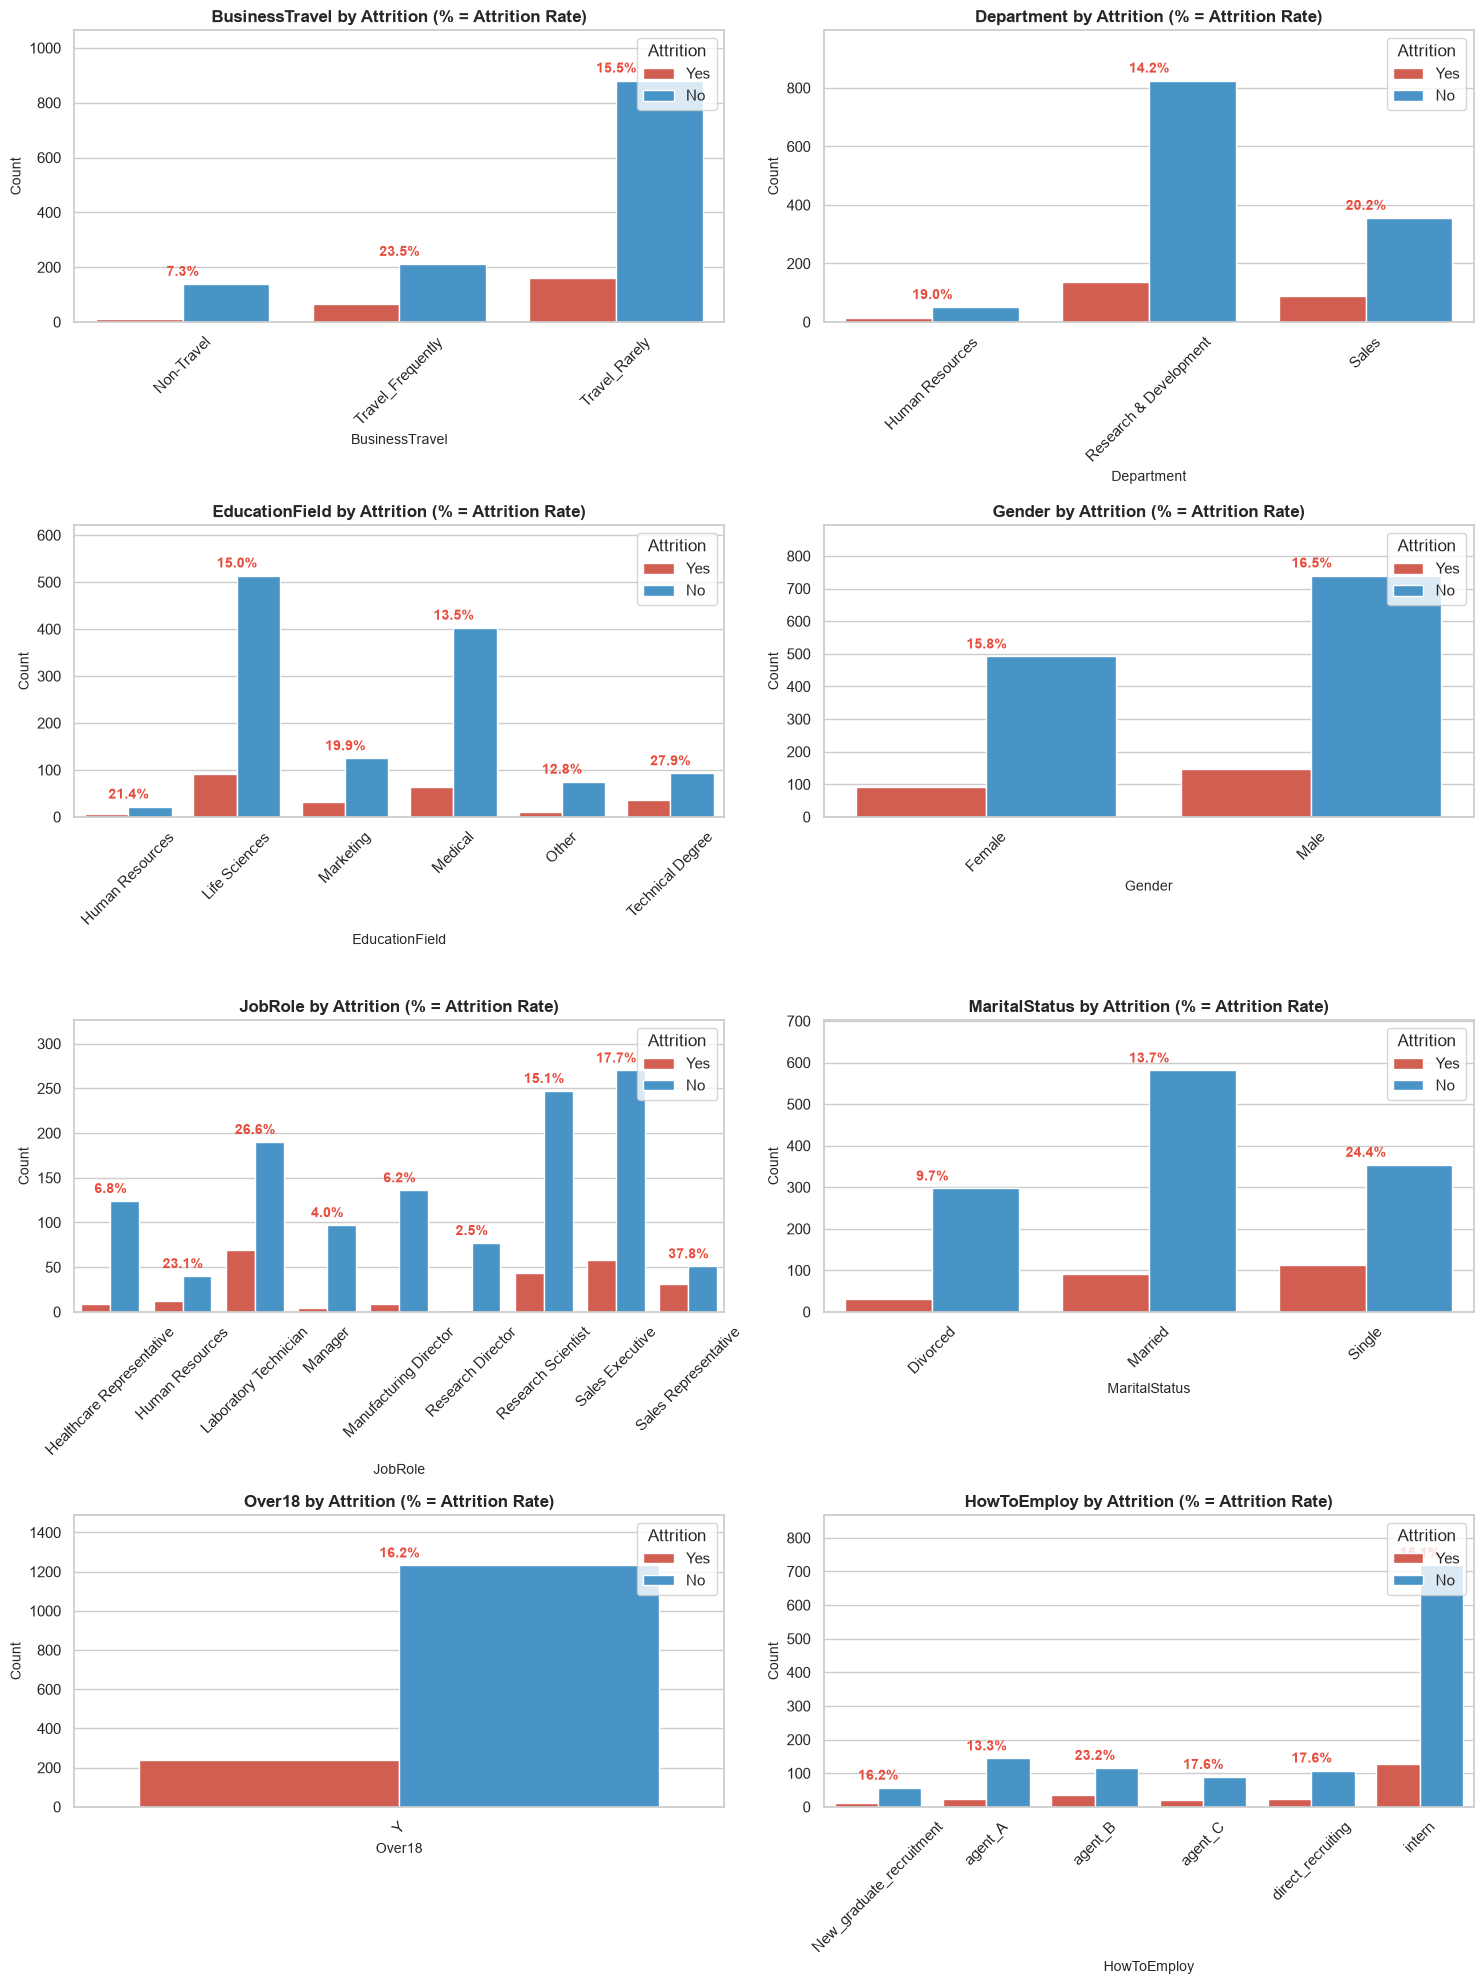

In [30]:
# Select categorical columns and exclude 'Attrition' (target variable)
obj_cols = df.select_dtypes(include="object").columns
obj_cols = [col for col in obj_cols if col != 'Attrition']

# Calculate grid size dynamically
n_cols_to_plot = len(obj_cols)
n_rows = math.ceil(n_cols_to_plot / 2)
n_cols_grid = min(2, n_cols_to_plot)

# Plot configurations
fig, axes = plt.subplots(n_rows, n_cols_grid, figsize=(15, n_rows * 5))

# Flatten axes for easy iteration
if n_cols_to_plot == 1:
    axes = [axes]
elif n_rows > 1:
    axes = axes.flatten()

for i, col in enumerate(obj_cols):
    ax = axes[i]

    # 1. Define fixed order (Crucial to prevent data misalignment)
    # Extract and sort unique categories that have values
    order_list = sorted(df[col].dropna().unique())

    # 2. Create the countplot
    sns.countplot(data=df, x=col, hue='Attrition', hue_order=['Yes', 'No'],
                ax=ax, palette={'No': '#3498db', 'Yes': '#e74c3c'},
                order=order_list) # Explicitly pass the order

    # 3. Aggregate data to calculate attrition rates and determine height
    # Count Yes/No occurrences per category
    counts = df.groupby([col, 'Attrition']).size().unstack(fill_value=0)

    # Get current y-axis limit to calculate relative offset
    y_max_limit = ax.get_ylim()[1]

    # Place text above the bars for each category
    for idx, category in enumerate(order_list):
        if category in counts.index:
            n_yes = counts.loc[category].get('Yes', 0)
            n_no = counts.loc[category].get('No', 0)
            total = n_yes + n_no

            # Calculate attrition rate
            rate = (n_yes / total * 100) if total > 0 else 0

            # Determine Y position for text:
            # Use the height of the taller bar (Yes or No) as the baseline
            max_bar_height = max(n_yes, n_no)
            text_y = max_bar_height + (y_max_limit * 0.02) # Add a small offset

            # Draw text (idx corresponds to the x-axis coordinate due to 'order')
            ax.text(idx, text_y,
                    f'{rate:.1f}%',
                    ha='center', va='bottom', fontsize=10, fontweight='bold',
                    color='#e74c3c')

    # Adjust layout settings
    ax.set_ylim(0, ax.get_ylim()[1] * 1.15) # Add extra space at the top for labels
    ax.set_title(f'{col} by Attrition (% = Attrition Rate)', fontsize=12, fontweight='bold')
    ax.set_xlabel(col, fontsize=10)
    ax.set_ylabel('Count', fontsize=10)
    ax.tick_params(axis='x', rotation=45)
    ax.legend(title='Attrition', loc='upper right')

# Hide extra subplots if any
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

#### Key Insights from Categorical Features:

## Data Preprocessing
### Handling Irrelevant Columns

In [31]:
# Check for columns with only 1 unique value
constant_cols = [col for col in df.columns if df[col].nunique() == 1]
print(f"Constant columns (1 unique value): {constant_cols}")

# Check EmployeeNumber
if 'EmployeeNumber' in df.columns:
    print(f"EmployeeNumber unique values: {df['EmployeeNumber'].nunique()} (Total rows: {len(df)}) -> This is an ID column.")

# Drop these columns
cols_to_drop = constant_cols + ['EmployeeNumber']
# Filter to ensure we only drop columns that exist
cols_to_drop = [c for c in cols_to_drop if c in df.columns]

print(f"\nDropping columns: {cols_to_drop}")
df_clean = df.drop(columns=cols_to_drop)

# Also encode Target Variable here
df_clean['Attrition'] = df_clean['Attrition'].apply(lambda x: 1 if x == 'Yes' else 0)

Constant columns (1 unique value): ['EmployeeCount', 'Over18', 'StandardHours']
EmployeeNumber unique values: 1442 (Total rows: 1470) -> This is an ID column.

Dropping columns: ['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber']


## Encoding Categorical Variables

In [32]:
# Identify categorical columns
cat_cols = df_clean.select_dtypes(include=['object']).columns

print(f"Number of categorical columns to encode: {len(cat_cols)}")
print(f"Columns: {list(cat_cols)}")

# Apply Label Encoding
for col in cat_cols:
    le = LabelEncoder()
    df_clean[col] = le.fit_transform(df_clean[col])

print("\nEncoding complete. Data shape:", df_clean.shape)
df_clean.head()

Number of categorical columns to encode: 7
Columns: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'HowToEmploy']

Encoding complete. Data shape: (1470, 40)


/var/folders/9x/dqbd0vwn2573yqw6z7s2g8_r0000gn/T/ipykernel_74602/1531953563.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df_clean.select_dtypes(include=['object']).columns


,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,PerformanceIndex,...,RemoteWork,MonthlyIncome,StressRating,WelfareBenefits,InHouseFacility,ExternalFacility,ExtendedLeave,FlexibleWork,StressSelfReported,Year
0,41,1,2,2,1,2,1,2,0,94,...,1,5224,4,1,0,0,0,0,1,2023
1,49,0,1,1,8,1,1,3,1,61,...,3,6863,2,4,1,0,0,1,1,2023
2,37,1,2,1,2,2,4,4,1,92,...,2,7612,3,2,1,0,0,0,1,2023
3,33,0,1,1,3,4,1,4,0,56,...,2,11245,1,4,1,1,1,1,1,2023
4,27,0,2,1,2,1,3,1,1,40,...,2,3029,3,2,0,0,0,0,3,2023


## Model Building (LightGBM)


In [33]:
# Split Data
X = df_clean.drop('Attrition', axis=1)
y = df_clean['Attrition']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Initialize LightGBM Dataset
train_data = lgb.Dataset(X_train, label=y_train)
test_data = lgb.Dataset(X_test, label=y_test, reference=train_data)

# Parameters
params = {
    'objective': 'binary',
    'metric': 'auc',
    'boosting_type': 'gbdt',
    'num_leaves': 31,
    'learning_rate': 0.05,
    'feature_fraction': 0.9,
    'verbose': -1,
    'is_unbalance': True # Handle class imbalance
}

# Train Model
lgb_model = lgb.train(
    params,
    train_data,
    num_boost_round=100,
    valid_sets=[test_data],
    callbacks=[lgb.early_stopping(stopping_rounds=10), lgb.log_evaluation(period=0)]
)

# Predictions
y_pred_proba = lgb_model.predict(X_test, num_iteration=lgb_model.best_iteration)

thresh = 0.5
y_pred = (y_pred_proba > thresh).astype(int)
f1 = f1_score(y_test, y_pred)

print(f"F1 Score: {f1:.4f}")

Training until validation scores don't improve for 10 rounds
Did not meet early stopping. Best iteration is:
[100]	valid_0's auc: 0.827179
F1 Score: 0.5197


In [34]:
# Importing the class for standardization
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# Setting X and y
X = df_clean.drop('Attrition', axis=1)
y = df['Attrition']

# Splitting into training and test data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=0)

# Standardization process
sc = StandardScaler()
sc.fit(X_train)
X_train_std = sc.transform(X_train)
X_test_std = sc.transform(X_test)

# Initializing and training the logistic regression class
model = LogisticRegression()
model.fit(X_train_std, y_train)

# Displaying the accuracy
print('Accuracy (train):{:.3f}'.format(model.score(X_train_std, y_train)))
print('Accuracy (test):{:.3f}'.format(model.score(X_test_std, y_test)))

Accuracy (train):0.876
Accuracy (test):0.869


## Evaluation


In [38]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

ValueError: Found input variables with inconsistent numbers of samples: [735, 441]

### Interpreting the Results

### Feature Importance

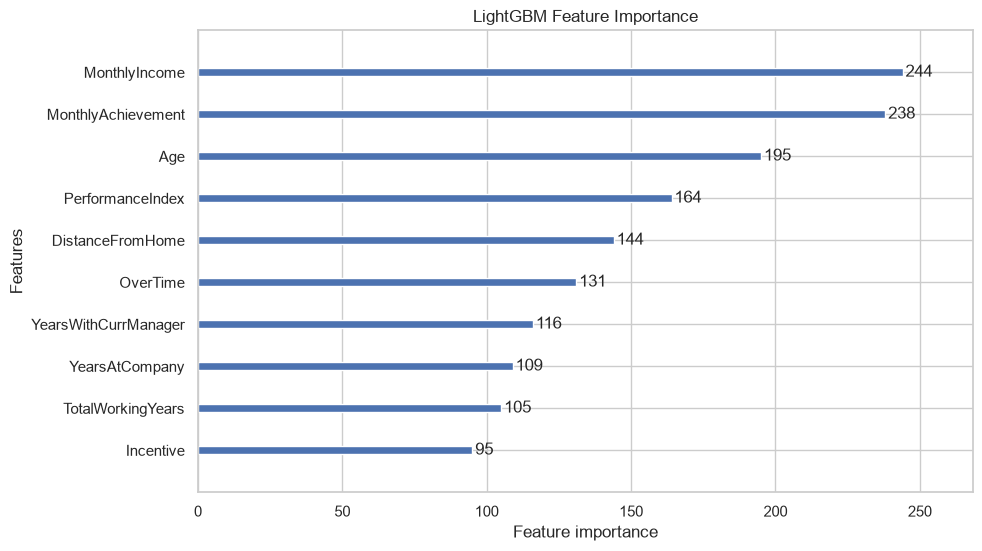

Top 10 Features: ['MonthlyIncome', 'MonthlyAchievement', 'Age', 'PerformanceIndex', 'DistanceFromHome', 'OverTime', 'YearsWithCurrManager', 'YearsAtCompany', 'TotalWorkingYears', 'Incentive']


In [39]:
lgb.plot_importance(lgb_model, max_num_features=10, figsize=(10, 6))
plt.title('LightGBM Feature Importance')
plt.show()

# Get top features for later use
importance = lgb_model.feature_importance()
feature_names = X.columns
feature_importance_df = pd.DataFrame({'feature': feature_names, 'importance': importance})
top_features = feature_importance_df.sort_values(by='importance', ascending=False).head(10)['feature'].tolist()
print("Top 10 Features:", top_features)

### Interpreting Feature Importance Results

##H ypothesis Testing on Important Features

In [40]:
print("Performing Mann-Whitney U Test on the top 5 features:\n")

# Get top 5 features
top_5_features = feature_importance_df.sort_values(by='importance', ascending=False).head(5)['feature'].tolist()

for col in top_5_features:
    # Group 1: Attrition = 1 (Yes)
    group_attrition_1 = df_clean[df_clean['Attrition'] == 1][col]
    # Group 2: Attrition = 0 (No)
    group_attrition_0 = df_clean[df_clean['Attrition'] == 0][col]

    # Perform Test
    stat, p_value = stats.mannwhitneyu(group_attrition_1, group_attrition_0)

    print(f"--- Feature: {col} ---")
    print(f"Statistic: {stat:.2f}, P-value: {p_value:.5e}")

    if p_value < 0.05:
        print("✓ Result: Significant difference (Reject H0)")
        print("  → This feature shows a real, statistically validated difference between groups")
    else:
        print("✗ Result: No significant difference (Fail to reject H0)")
        print("  → Difference might be due to random chance, needs further investigation")

Performing Mann-Whitney U Test on the top 5 features:

--- Feature: MonthlyIncome ---
Statistic: 121097.00, P-value: 2.08958e-05
✓ Result: Significant difference (Reject H0)
  → This feature shows a real, statistically validated difference between groups
--- Feature: MonthlyAchievement ---
Statistic: 146672.50, P-value: 9.91483e-01
✗ Result: No significant difference (Fail to reject H0)
  → Difference might be due to random chance, needs further investigation
--- Feature: Age ---
Statistic: 107178.50, P-value: 4.68218e-11
✓ Result: Significant difference (Reject H0)
  → This feature shows a real, statistically validated difference between groups
--- Feature: PerformanceIndex ---
Statistic: 143363.00, P-value: 5.88345e-01
✗ Result: No significant difference (Fail to reject H0)
  → Difference might be due to random chance, needs further investigation
--- Feature: DistanceFromHome ---
Statistic: 162913.00, P-value: 6.35086e-03
✓ Result: Significant difference (Reject H0)
  → This feature 

## Hypothesis Testing Results Interpretation

## Simulation on Important Factors from Section 7

In [41]:
# Simulation on Important Factors
# 1. Identify High Risk Employees
y_pred_proba = lgb_model.predict(X_test, num_iteration=lgb_model.best_iteration)

threshold = 0.5

high_risk_indices = np.where(y_pred_proba > threshold)[0]
X_high_risk = X_test.iloc[high_risk_indices].copy()
print(f"High Risk Employees Count: {len(X_high_risk)}")

# 2. Apply Interventions
X_simulated = X_high_risk.copy()

# MonthlyIncome: +10%
if 'MonthlyIncome' in X_simulated.columns:
    X_simulated['MonthlyIncome'] = X_simulated['MonthlyIncome'] * 1.10

# DistanceFromHome: -50%
if 'DistanceFromHome' in X_simulated.columns:
    X_simulated['DistanceFromHome'] = X_simulated['DistanceFromHome'] * 0.5


# 3. Predict Again
y_pred_sim_proba = lgb_model.predict(X_simulated, num_iteration=lgb_model.best_iteration)
y_pred_sim = (y_pred_sim_proba > threshold).astype(int)

# 4. Calculate Impact
original_attrition = len(X_high_risk)
remaining_attrition = np.sum(y_pred_sim)
saved_employees = original_attrition - remaining_attrition
conversion_rate = saved_employees / original_attrition * 100

print(f"Original Attrition Prediction: {original_attrition}")
print(f"Remaining Attrition Prediction: {remaining_attrition}")
print(f"Saved Employees (No Attrition): {saved_employees}")
print(f"Conversion Rate: {conversion_rate:.2f}%")

High Risk Employees Count: 109
Original Attrition Prediction: 109
Remaining Attrition Prediction: 95
Saved Employees (No Attrition): 14
Conversion Rate: 12.84%
